# 淘宝用户购物行为数据可视化分析

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
sns.set_context('notebook')

In [2]:
data_user = pd.read_csv('user_action.csv')

## 数据处理

In [11]:
data_user.head()
# 用户id、商品id、行为id、商品类别id、行为时间

,user_id,item_id,behavior_type,item_category,time
0,98047837,232431562,1,4245,2014-12-06 02
1,97726136,383583590,1,5894,2014-12-09 20
2,98607707,64749712,1,2883,2014-12-18 11
3,98662432,320593836,1,6562,2014-12-06 10
4,98145908,290208520,1,13926,2014-12-16 21


In [19]:
# 查看总行为记录条数、总用户规模、商品类型总数、商品类别数
print('总行为记录条数:' , len(data_user['user_id']))
print('总用户规模:' ,len(set(data_user['user_id'])))
print('商品类型总数:' ,len(set(data_user['item_id'])))
print('商品类别数:' ,len(set(data_user['item_category'])))

总行为记录条数: 12256906
总用户规模: 10000
商品类型总数: 2876947
商品类别数: 8916


In [20]:
# 查看每列的缺失值情况
data_user.isnull().sum()

user_id          0
item_id          0
behavior_type    0
item_category    0
time             0
dtype: int64

In [3]:
# 拆分‘time’一列的日期和时间
data_user['date'] = data_user['time'].apply(lambda x: x.split(' ')[0])
data_user['hour'] = data_user['time'].apply(lambda x: x.split(' ')[1])
data_user.drop(['time'], axis = 1, inplace = True)
data_user.head()

,user_id,item_id,behavior_type,item_category,date,hour
0,98047837,232431562,1,4245,2014-12-06,02
1,97726136,383583590,1,5894,2014-12-09,20
2,98607707,64749712,1,2883,2014-12-18,11
3,98662432,320593836,1,6562,2014-12-06,10
4,98145908,290208520,1,13926,2014-12-16,21


In [18]:
data_user.dtypes

user_id           int64
item_id           int64
behavior_type     int64
item_category     int64
date             object
hour             object
dtype: object

In [4]:
# 数据类型转化
data_user['date'] = pd.to_datetime(data_user['date'])
int64_columns = data_user.dtypes[data_user.dtypes == 'int64'].index
data_user[int64_columns] = data_user[int64_columns].astype('object')
data_user['hour'] = data_user['hour'].astype('int64')
data_user.dtypes

user_id                  object
item_id                  object
behavior_type            object
item_category            object
date             datetime64[ns]
hour                      int64
dtype: object

## 数据可视化

## Part1. 流量分析

访问量(PV)：全名为Page View, 基于用户每次对淘宝页面的刷新次数，用户每刷新一次页面或者打开新的页面就记录就算一次访问。 

独立访问量(UV)：全名为Unique Visitor，一个用户若多次访问淘宝只记录一次。

### 1、计算天级别的访问量和独立访问量

In [53]:
# 计算每日的 pv
pv_daily = data_user.groupby('date')['user_id'].count()
pv_daily = pv_daily.reset_index()

In [54]:
pv_daily = pv_daily.rename(columns = {'user_id':'pv_daily'})
pv_daily.head()

,date,pv_daily
0,2014-11-18,366701
1,2014-11-19,358823
2,2014-11-20,353429
3,2014-11-21,333104
4,2014-11-22,361355


In [55]:
# 计算每日的 uv
uv_daily = data_user.groupby('date')['user_id'].apply(lambda x: len(x.unique())) # 这里的 x 不是单个 user_id，而是每个日期分组中的所有 user_id 组成的 Series
uv_daily = uv_daily.reset_index()
uv_daily = uv_daily.rename(columns = {'user_id':'uv_daily'})
uv_daily.head()

,date,uv_daily
0,2014-11-18,6343
1,2014-11-19,6420
2,2014-11-20,6333
3,2014-11-21,6276
4,2014-11-22,6187


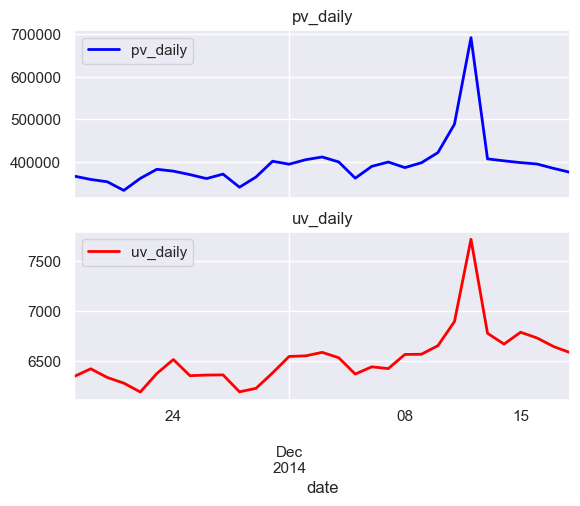

In [65]:
# 可视化--面向对象
fig, axes = plt.subplots(2,1, sharex = True)
pv_daily.plot(x = 'date', y = 'pv_daily', ax = axes[0], color = 'blue', linewidth = 2)
uv_daily.plot(x = 'date', y = 'uv_daily', ax = axes[1], color = 'red', linewidth = 2)
axes[0].set_title('pv_daily')
axes[1].set_title('uv_daily')
plt.show()
plt.close('all')

### 2、计算小时级别的访问量和独立访问量

In [69]:
# 计算每小时的 pv
pv_hour = data_user.groupby('hour')['user_id'].count()
pv_hour = pv_hour.reset_index()
pv_hour = pv_hour.rename(columns = {'user_id':'pv_hour'})
pv_hour.head(24)

,hour,pv_hour
0,0,517404
1,1,267682
2,2,147090
3,3,98516
4,4,80487
5,5,88296
6,6,158798
7,7,287337
8,8,396106
9,9,485951


In [71]:
# 计算每小时的uv
uv_hour = data_user.groupby('hour')['user_id'].apply(lambda x: len(x.unique()))
uv_hour = uv_hour.reset_index()
uv_hour = uv_hour.rename(columns = {'user_id':'uv_hour'})
uv_hour.head(24)

,hour,uv_hour
0,0,5786
1,1,3780
2,2,2532
3,3,1937
4,4,1765
5,5,2030
6,6,3564
7,7,5722
8,8,7108
9,9,7734


<Figure size 640x480 with 0 Axes>

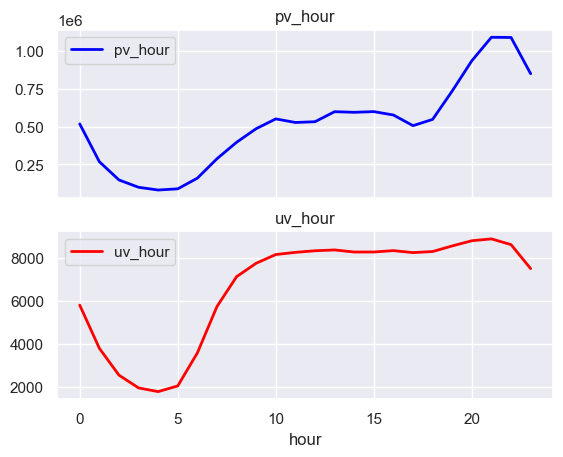

In [73]:
# 可视化
fig, axes = plt.subplots(2,1, sharex = True)
pv_hour.plot(x = 'hour', y = 'pv_hour', ax = axes[0], color = 'blue', linewidth = 2)
uv_hour.plot(x = 'hour', y = 'uv_hour', ax = axes[1], color = 'red', linewidth = 2)
axes[0].set_title('pv_hour')
axes[1].set_title('uv_hour')
plt.show()

从“日PV/UV”趋势看，双十二当天的总体流量会出现明显的峰值。那么双十二当天基于小时的用户访问数据会有变化吗？

In [87]:
data_user_1212 = data_user[data_user['date']=='2014-12-12']

In [89]:
pv_hour_1212 = data_user_1212.groupby('hour')['user_id'].count().reset_index().rename(columns = {'user_id':'pv_hour_1212'})
uv_hour_1212 = data_user_1212.groupby('hour')['user_id'].apply(lambda x: len(x.unique())).reset_index().rename(columns = {'user_id':'uv_hour_1212'})

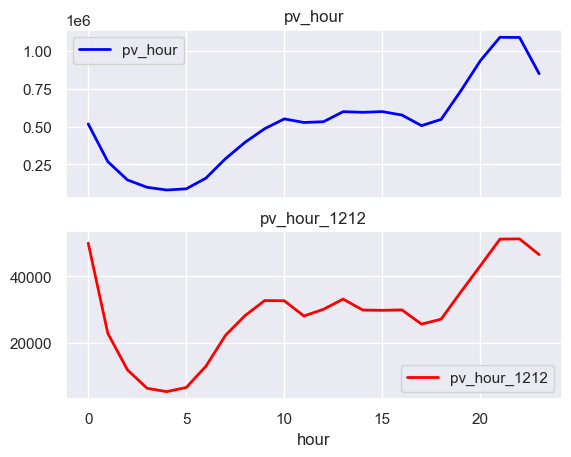

In [91]:
fig, axes = plt.subplots(2,1, sharex = True)
pv_hour.plot(x = 'hour', y = 'pv_hour', ax = axes[0], color = 'blue', linewidth = 2)
pv_hour_1212.plot(x = 'hour', y = 'pv_hour_1212', ax = axes[1], color = 'red', linewidth = 2)
axes[0].set_title('pv_hour')
axes[1].set_title('pv_hour_1212')
plt.show()

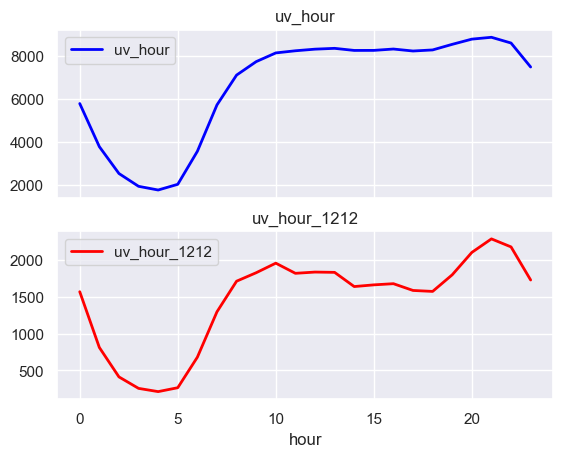

In [92]:
fig, axes = plt.subplots(2,1, sharex = True)
uv_hour.plot(x = 'hour', y = 'uv_hour', ax = axes[0], color = 'blue', linewidth = 2)
uv_hour_1212.plot(x = 'hour', y = 'uv_hour_1212', ax = axes[1], color = 'red', linewidth = 2)
axes[0].set_title('uv_hour')
axes[1].set_title('uv_hour_1212')
plt.show()

### 3. 不同用户行为流量分析

淘宝用户分布广泛，不同的用户的购物行为有较大差异。比如不同的用户的登录习惯以及购买偏好，因此按照用户的角度进行分析是重要且有趣的。因此我们依旧从用户访问量的这一数据来分析不同用户的浏览淘宝的习惯。

为了获得用户的行为模式，主要统计在一天当中（按照每小时）用户发生的行为。因此使用groupby进行数据分组，方式如下：

In [10]:
pv_behavior = data_user.groupby(['behavior_type', 'hour'])['user_id'].count().reset_index().rename(columns = {'user_id':'pv_behavior'})
pv_behavior

,behavior_type,hour,pv_behavior
0,1,0,487341
1,1,1,252991
2,1,2,139139
3,1,3,93250
4,1,4,75832
...,...,...,...
91,4,19,6352
92,4,20,7872
93,4,21,8829
94,4,22,8845


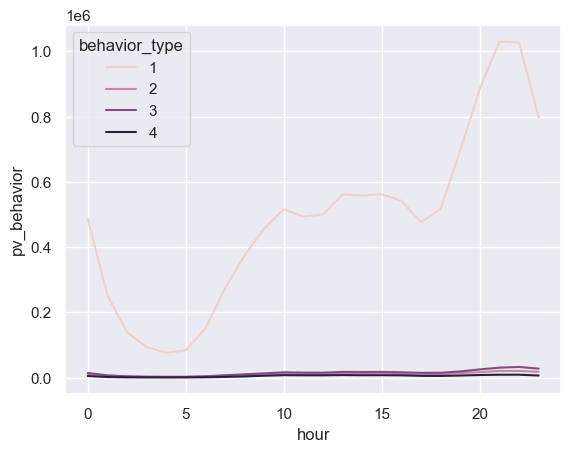

In [11]:
# 可视化
# hue='behavior_type'：分组变量，按行为类型用不同颜色区分
ax = sns.lineplot(x = 'hour', y = 'pv_behavior', hue = 'behavior_type', data = pv_behavior)

因为action_type为1（浏览行为）的占比非常大，导致上图其它几类action的趋势不太明显，去掉action_type为1的数据后再来看看

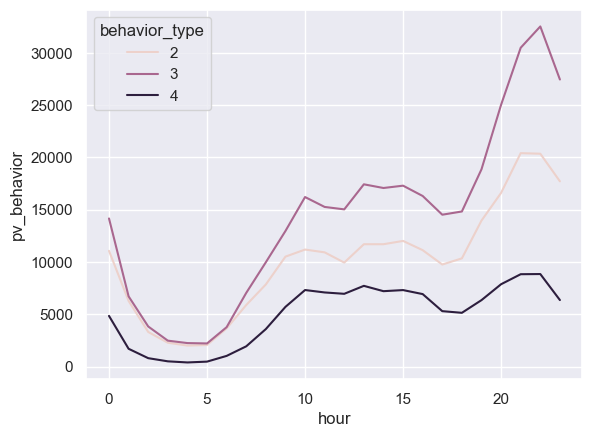

In [12]:
ax = sns.lineplot(x = 'hour', y = 'pv_behavior', hue = 'behavior_type', data = pv_behavior[pv_behavior.behavior_type != 1])
# 点击、收藏、加购物车、支付四种行为，分别用数字1、2、3、4表示

In [13]:
pv_behavior_1212 = data_user[data_user.date == '2014-12-12'].groupby(['behavior_type', 'hour'])['user_id'].count().reset_index().rename(columns = {'user_id':'pv_behavior_1212'})

分析：
    可以看出4种行为按照小时的变化趋势基本一致，都是在晚上8点之后有明显增长，凌晨2-6点是低峰，符合常识

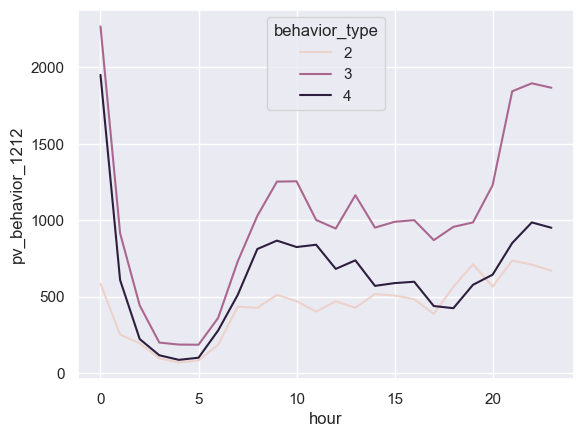

In [15]:
ax1 = sns.lineplot(x = 'hour', y = 'pv_behavior_1212', hue = 'behavior_type', 
                   data = pv_behavior_1212[pv_behavior_1212.behavior_type != 1])

分析：
    在双十二当天， 收藏行为明显较平日减少，加购物车和支付行为趋势与往常差不多，这与双十二活动大力促销有关，用户在这一天集中支付会有更多优惠，相反收藏行为在这一天显得有些“此时不付待何时？”

## Part2. 转化率分析

分析“浏览-收藏/加购-购买”链路的转化漏斗模型，可以帮助我们更好的了解各个环节的转化链路

In [20]:
# 查看每个环节的访问人次
behavior_cnt = data_user.groupby('behavior_type')['user_id'].count()
behavior_cnt

behavior_type
1    11550581
2      242556
3      343564
4      120205
Name: user_id, dtype: int64

可以看到，用户浏览（action_type=1）的基数是最大的，因为加购和收藏没有必然联系，因此我们把这两类合并在一起做分析：

In [67]:
# 计算每个环节的转化率
click_num, fav_num, add_num, pay_num = behavior_cnt[1], behavior_cnt[2], behavior_cnt[3], behavior_cnt[4]
fav_add_num = fav_num + add_num

print(f'点击->加购/收藏的转化率：{fav_add_num / click_num*100:.2f}%')
print(f'加购/收藏->支付的转化率：{pay_num / fav_add_num*100:.2f}%')
print(f'点击->支付的转化率: {pay_num / click_num*100:.2f}%')

点击->加购/收藏的转化率：5.07%
加购/收藏->支付的转化率：20.51%
点击->支付的转化率: 1.04%


分析：
可以观察到，从浏览到加购/收藏的转化率大约5%；“加购/收藏”后到购买转化率大约为20%，这个比例还是还是非常高的，说明用户感兴趣的商品更容易成单。 两者相乘，我们能粗略估出从浏览到购买的转化率约为1%左右。

再来看看双十二当天的数据，看看是否有不同的结论？

In [33]:
behavior_cnt_1212 = data_user[data_user['date'] == '2014-12-12'].groupby('behavior_type')['user_id'].count()
behavior_cnt_1212

behavior_type
1    641507
2     10446
3     24508
4     15251
Name: user_id, dtype: int64

In [66]:
click_num_1212, fav_num_1212, add_num_1212, pay_num_1212 = behavior_cnt_1212[1], behavior_cnt_1212[2], behavior_cnt_1212[3], behavior_cnt_1212[4]
fav_add_num_1212 = fav_num_1212 + add_num_1212

print(f'点击->加购/收藏的转化率：{fav_add_num_1212 / click_num_1212*100:.2f}%')
print(f'加购/收藏->支付的转化率：{pay_num_1212 / fav_add_num_1212*100:.2f}%')
print(f'点击->支付的转化率: {pay_num_1212 / click_num_1212*100:.2f}%')

点击->加购/收藏的转化率：5.45%
加购/收藏->支付的转化率：43.63%
点击->支付的转化率: 2.38%


分析：可以看出，双十二当天，加购/收藏 到 购买转化率是平时的2倍之多，此外，加购/收藏 的转化率也比平时高出不少，说明大促的运营活动对用户活跃度的转化起到了很好的促进作用。在双十二这天，用户在这天一般会选择将之前加购/收藏的商品支付以换取优惠，所以加购/收藏->支付的转化率、点击->支付的转化率均有明显提升。

作为商家来讲，可以考虑在特定节日推出特定主题的优惠活动，是个有效的促活、转化的方式。

## Part3. 用户价值分析

在分析完整体变化趋势和转化率之后，商家更关注的是用户行为，什么用户是有价值的，什么用户是潜在用户？商业上已经有不少成熟的模型可供参考，如用户价值RFM分析模型等，在此不做详细解释。本项目中我们还是从实际问题出发，站在用户购买行为的角度来探索用户价值：

### 4. 用户购买频次分析

从上面的统计结果来看，用户的点击数据是最多的，但是从淘宝盈利的角度来说，只有购买行为是商家最为关注的，这里就会引入一个问题：在给定的数据集上，淘宝用户购买东西的频次有多少？基于这个问题，我们可以用统计的方法计算。计算结果如下：

In [37]:
data_user_buy = data_user[data_user['behavior_type'] == 4].groupby('user_id')['behavior_type'].count().reset_index().rename(columns = {'behavior_type':'buy_cnt'})
data_user_buy

,user_id,buy_cnt
0,4913,6
1,6118,1
2,7528,6
3,7591,21
4,12645,8
...,...,...
8881,142376113,1
8882,142412247,12
8883,142430177,5
8884,142450275,40


<Axes: xlabel='user_id'>

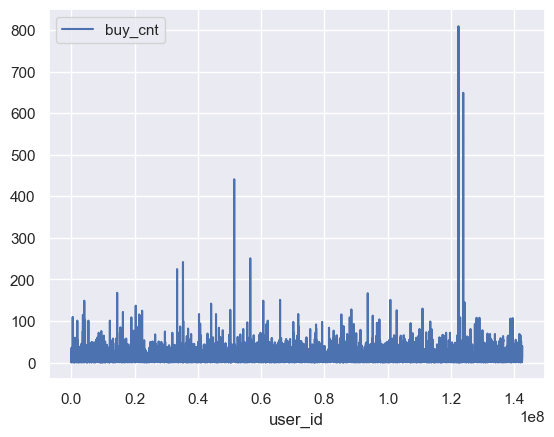

In [39]:
# 柱状图可视化每个购买用户的一年购买总次数
data_user_buy.plot(x = 'user_id', y = 'buy_cnt')

分析：可以看出一年内大部分用户的购买次数不超过50，这期间还包括了双十二当天的集中购物，排除双十二高峰，实际消费次数会更少，个别用户购买次数达到了上百次，像这样的就是忠实用户，可以重点维护。

### 5. ARPU分析

ARPU(Average Revenue Per User) 表示每日的收益在所有活跃用户中的转化。详细的描述为，每日的所有收益与每日的活跃的用户数量有关，因此可以通过ARPU来计算，每日活跃用户对每日收益的转化效率。

该数据集中没有对金额的体现。那我们可以对ARPU这个指标做一些修改，改为度量平台活跃用户每日平均消费次数。

计算公式为： ARPU = 每日消费总次数 / 每日活跃用户数|

In [6]:
# 计算每日用户的平均消费次数
# 得到每个用户在每日的各个行为的次数
data_user['action'] = 1  # 用来计数
data_user_arpu = data_user.groupby(['date', 'user_id', 'behavior_type'])['action'].count().reset_index()
data_user_arpu

,date,user_id,behavior_type,action
0,2014-11-18,4913,1,27
1,2014-11-18,4913,2,1
2,2014-11-18,7591,1,4
3,2014-11-18,12645,1,25
4,2014-11-18,54056,1,13
...,...,...,...,...
375435,2014-12-18,142430177,3,2
375436,2014-12-18,142430177,4,1
375437,2014-12-18,142450275,1,272
375438,2014-12-18,142450275,2,3


In [47]:
arpu = data_user_arpu.groupby('date').apply(lambda x:x[x['behavior_type'] == 4]['action'].sum() / len(x['user_id'].unique()))
arpu

C:\Users\86150\AppData\Local\Temp\ipykernel_10652\116362703.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arpu = data_user_arpu.groupby('date').apply(lambda x:x[x['behavior_type'] == 4]['action'].sum() / len(x['user_id'].unique()))


date
2014-11-18    0.588050
2014-11-19    0.574143
2014-11-20    0.546660
2014-11-21    0.481358
2014-11-22    0.577016
2014-11-23    0.525184
2014-11-24    0.526025
2014-11-25    0.545426
2014-11-26    0.562058
2014-11-27    0.577135
2014-11-28    0.519955
2014-11-29    0.515906
2014-11-30    0.566860
2014-12-01    0.597341
2014-12-02    0.552824
2014-12-03    0.589977
2014-12-04    0.565151
2014-12-05    0.521282
2014-12-06    0.508075
2014-12-07    0.507007
2014-12-08    0.520871
2014-12-09    0.525282
2014-12-10    0.483464
2014-12-11    0.467943
2014-12-12    1.975518
2014-12-13    0.513282
2014-12-14    0.522346
2014-12-15    0.554590
2014-12-16    0.560410
2014-12-17    0.544182
2014-12-18    0.544819
dtype: float64

Text(0.5, 1.0, 'ARPU')

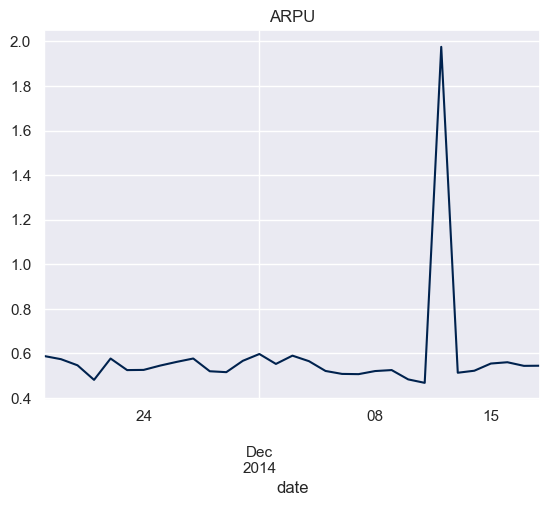

In [50]:
arpu.plot(colormap='cividis')
plt.title('ARPU')

分析：可以看到，活跃用户每天平均消费次数在0.5次左右，双十二期间达到最高值接近2，是平时的4倍左右，表明用户会集中在大促日的时候购买。

### 6. ARPPU分析

ARPPU(average revenue per paying user)是指从每位付费用户中获得的收益，它反映的是整个平台的用户消费的均值。

它的计算方式为：ARPPU = 总收入/活跃用户付费数量。但是在该数据集中没有收益金额，因此我们可以对计算方式做一点转化，将总收入转化为总的购买行为次数。

定义如下：ARPPU = 当日总消费次数/当日活跃用户付费数量 ， 可以看出和ARPU唯一的区别是分母，ARPU的分母是活跃用户数（包含4种行为类型），ARPPU的分母是活跃付费用户数，因此ARPPU的计算会更简单：

In [51]:
arppu = data_user_arpu[data_user_arpu['behavior_type'] == 4].groupby('date').apply(lambda x: x['action'].sum() / len(x['user_id'].unique()))
arppu

C:\Users\86150\AppData\Local\Temp\ipykernel_10652\734544014.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arppu = data_user_arpu[data_user_arpu['behavior_type'] == 4].groupby('date').apply(lambda x: x['action'].sum() / len(x['user_id'].unique()))


date
2014-11-18    2.423652
2014-11-19    2.439444
2014-11-20    2.320375
2014-11-21    2.271429
2014-11-22    2.530120
2014-11-23    2.330780
2014-11-24    2.248031
2014-11-25    2.313961
2014-11-26    2.402824
2014-11-27    2.403405
2014-11-28    2.231623
2014-11-29    2.331881
2014-11-30    2.357236
2014-12-01    2.359083
2014-12-02    2.284543
2014-12-03    2.289334
2014-12-04    2.328707
2014-12-05    2.223041
2014-12-06    2.253444
2014-12-07    2.320741
2014-12-08    2.204384
2014-12-09    2.413576
2014-12-10    2.230236
2014-12-11    2.226363
2014-12-12    3.913523
2014-12-13    2.245320
2014-12-14    2.312749
2014-12-15    2.313460
2014-12-16    2.285455
2014-12-17    2.302548
2014-12-18    2.310567
dtype: float64

Text(0.5, 1.0, 'ARPPU')

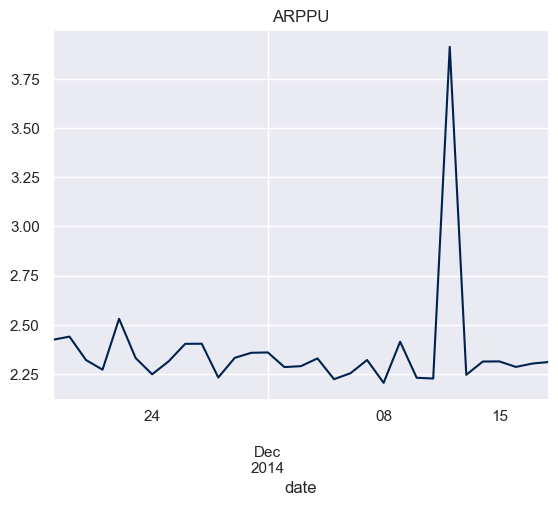

In [52]:
arppu.plot(colormap = 'cividis')
plt.title('ARPPU')

分析：可以看到，针对活跃的下单用户来讲，平均每日消费次数在2-2.5次之间波动，双十二当天该数值达超过3.75，一个可能的原因是用户会在平时把喜欢的商品进行加购，等到双十二促销当天再下单购买。

### 7. 复购情况分析

一般来说，复购是指对产品的重复购买行为。但是这个定义在商业上是不精确的，假若一个用户在一天内多次在淘宝购买商品，不能说明这件用户对淘宝的依赖（有可能是某位用户只是第一次用，但是买的量大）。因此商业分析过程中，对于复购行为进行明确的定义。这里的复购是指：两天以上都在该平台产生了购买行为，需要指出一天多次的购买不算是复购。

因此复购率的计算方式为：复购率 = 复购用户数量 / 有购买行为的用户数量。基于这个公式，我们先计算用户在数据集中的购买频次：

In [58]:
data_user_pay = data_user[data_user.behavior_type == 4]
data_user_pay = data_user_pay.groupby('user_id')['date'].apply(lambda x: len(x.unique()))
data_user_pay

user_id
4913         5
6118         1
7528         6
7591         9
12645        4
            ..
142376113    1
142412247    7
142430177    5
142450275    8
142455899    7
Name: date, Length: 8886, dtype: int64

In [65]:
# 计算复购率
repeat_buy_retio = data_user_pay[data_user_pay > 1].count() / data_user_pay.count()
print(f'复购率：{repeat_buy_retio.item()*100:.2f}%')
# .item() 返回标量值
# .values() 返回numpy数组

复购率：87.17%


复购率很高，达到了0.87

### 8. 复购周期分析

除了以上对复购频次的统计，还需要对复购意向做进一步的探究，想要知道用户多久复购一次。这个数据有助于淘宝产品宣传在这个时间间隔内采取策略，增加用户的复购意向，最终转化为实际收益

In [75]:
# 给出每个用户的购买日期分布
data_user_date = data_user[data_user.behavior_type == 4].groupby(['user_id','date'])['action'].count().reset_index()
data_user_date

,user_id,date,action
0,4913,2014-12-01,1
1,4913,2014-12-07,2
2,4913,2014-12-11,1
3,4913,2014-12-13,1
4,4913,2014-12-16,1
...,...,...,...
49196,142455899,2014-11-24,1
49197,142455899,2014-11-26,2
49198,142455899,2014-11-30,1
49199,142455899,2014-12-03,1


In [83]:
# 计算前后两次购买日期的天数之差
# diff(1) 表示与前一行的差值
data_date_diff = data_user_date.groupby('user_id').date.apply(lambda x: x.sort_values().diff(1)).dropna()
data_date_diff = data_date_diff.apply(lambda x: x.days)

Text(0, 0.5, 'count')

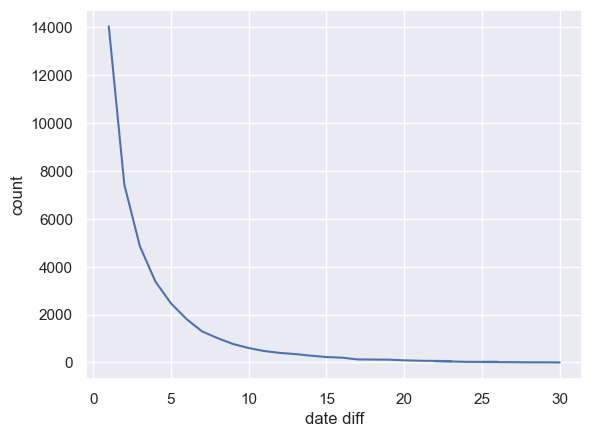

In [84]:
# value_counts() 统计每个值出现的频率，返回一个 Series，索引是时间间隔，值是该间隔出现的次数
data_date_diff.value_counts().plot(kind = 'line')
plt.xlabel('date diff')
plt.ylabel('count')

分析：可以看出，大部分用户的复购行为发生在5天之内，在第5天复购的行为出现了明显的拐点，如果这个时候采取营销策略提升用户的购买意图，增加更多收益。超过15天后，复购的意愿基本已经趋于0，此时可以考虑采取一些召回策略，增加复购的可能性，防止用户的流失。

## Part4. 淘宝网top10浏览量最大/购买次数最多的商品/商品类目

### 9. 淘宝网top10浏览量的商品类目

In [7]:
data_category = data_user.groupby('item_category')['action'].count()
data_category

item_category
2            3
3            3
4            1
6           10
8          993
         ...  
14075       48
14076       29
14078       60
14079    98190
14080       90
Name: action, Length: 8916, dtype: int64

In [8]:
data_category.sort_values(ascending = False)[:10]

item_category
1863     393247
13230    356773
5027     334280
5894     330207
6513     295768
5399     281739
11279    187056
2825     163626
5232     144200
10894    138782
Name: action, dtype: int64

### 10. 淘宝网top10购买量的商品类目

In [9]:
data_buy_category = data_user[data_user.behavior_type == 4].groupby('item_category')['action'].count()
data_buy_category.sort_values(ascending = False)[:10]

item_category
6344    2208
1863    2000
5232    1611
6977    1324
8877    1072
6513    1059
5399    1054
3424    1053
3472    1038
7957     997
Name: action, dtype: int64

分析：
1. 对于高浏览量类目（如1863、13230）

✅ 优化产品详情页和购买流程

✅ 针对浏览用户进行再营销

✅ 分析为何浏览量高但购买量相对不高

2. 对于高购买量类目（如6344、1863）

✅ 保证库存充足

✅ 重点投放广告资源

✅ 分析成功因素并复制到其他类目

### 11. 淘宝网top10转化率的商品类目

In [10]:
category_conversion = (data_buy_category / data_category).sort_values(ascending = False)

In [14]:
category_conversion[:10]

item_category
90       1.000000
8144     1.000000
11844    0.500000
4527     0.500000
7628     0.500000
12895    0.400000
369      0.333333
5069     0.333333
6488     0.266667
6668     0.259259
Name: action, dtype: float64

3. 对于高转化类目

✅ 作为重点发展类目

✅ 扩大同类商品规模

✅ 研究其目标用户特征

In [12]:
# # 找出高浏览量高购买量的类目
high_traffic_high_conversion = data_category[data_category > 100000].index.intersection(data_buy_category[data_buy_category > 1000].index)
high_traffic_high_conversion

Index([1863, 5232, 5399, 6513], dtype='int64', name='item_category')

这个分析揭示了淘宝平台上不同商品类目的用户行为差异，为商品运营、广告投放和库存管理提供了重要依据。